Project Title: Housing Price Prediction using Logistic Regression

Project Statement:

This project focuses on predicting housing prices using the Logistic Regression algorithm. The dataset used for this project was sourced from Kaggle and contains various features such as location, size, number of bedrooms, and other relevant attributes that influence house prices.

The dataset was first preprocessed by handling missing values, encoding categorical variables, and normalizing numerical features. Logistic Regression was then applied to classify housing prices into categories (such as low, medium, and high price ranges) based on the input features.

The model was trained and tested using standard machine learning techniques, including data splitting and evaluation metrics like accuracy, precision, and recall. The goal of the project is to demonstrate how classification algorithms like Logistic Regression can be used effectively in real-world scenarios such as real estate price prediction.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("Housing.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Housing.csv'

In [36]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [37]:
#select numerical columns
num_cols=df.select_dtypes(include=['int64','float64'])
num_cols.head()



,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


In [38]:
#select categorical column
category_cols=df.select_dtypes(include=['object'])
category_cols.head()


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished


In [39]:
#descriptive stats
#describing price
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

UNIVARIATE ANALYSIS ON AREA

In [40]:
df['area'].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

([<matplotlib.axis.XTick at 0x1d14fdf1450>,
 [Text(0, 0, '0'),
  Text(3000, 0, '3000'),
  Text(6000, 0, '6000'),
  Text(9000, 0, '9000'),
  Text(12000, 0, '12000'),
  Text(15000, 0, '15000')])

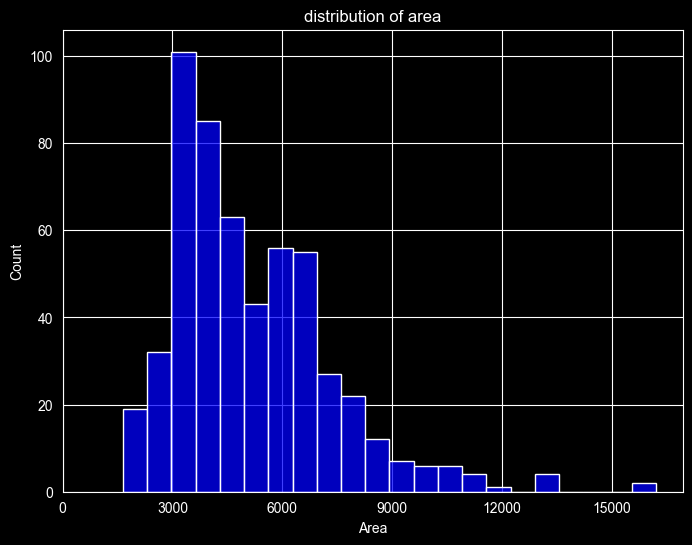

In [41]:
plt.figure(figsize=(8,6))
sns.histplot(df['area'],bins='auto',color='blue')
plt.title('distribution of area')
plt.xlabel('Area')
plt.ylabel('Count')
plt.xticks(np.arange(0, 16000, 3000))


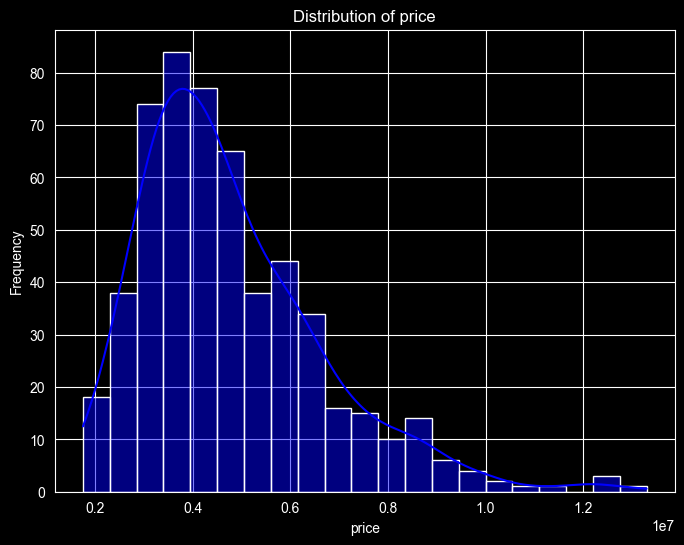

summary descriptive statistics of price
              price
count  5.450000e+02
mean   4.766729e+06
std    1.870440e+06
min    1.750000e+06
25%    3.430000e+06
50%    4.340000e+06
75%    5.740000e+06
max    1.330000e+07



### Analysis for **price**
- **Skewness:** Right-skewed (Positive) (Value: 1.21)
- **Most Frequent Range:** The data most often falls between `3400000.00 to 3950000.00`.
- **Least Frequent Range:** The data least often falls between `11650000.00 to 12200000.00`.
---


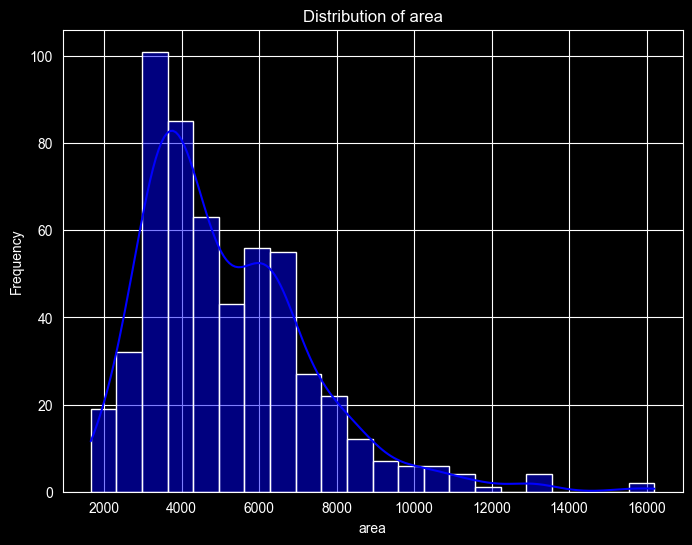

summary descriptive statistics of area
               area
count    545.000000
mean    5150.541284
std     2170.141023
min     1650.000000
25%     3600.000000
50%     4600.000000
75%     6360.000000
max    16200.000000



### Analysis for **area**
- **Skewness:** Right-skewed (Positive) (Value: 1.32)
- **Most Frequent Range:** The data most often falls between `2972.73 to 3634.09`.
- **Least Frequent Range:** The data least often falls between `12231.82 to 12893.18`.
---


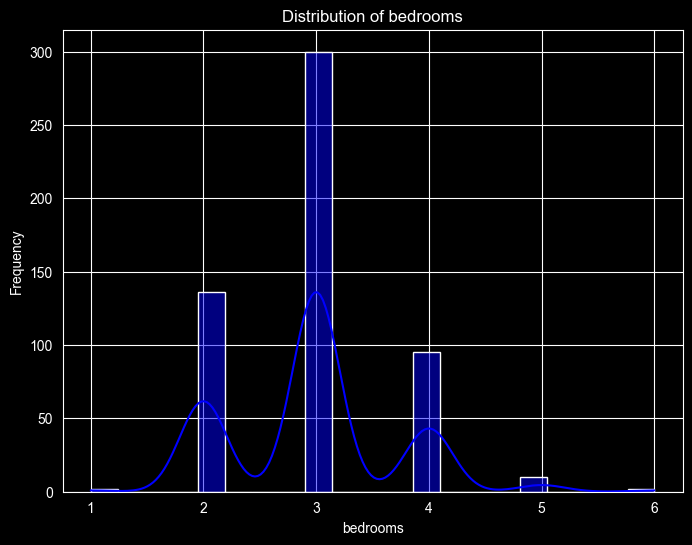

summary descriptive statistics of bedrooms
         bedrooms
count  545.000000
mean     2.965138
std      0.738064
min      1.000000
25%      2.000000
50%      3.000000
75%      3.000000
max      6.000000



### Analysis for **bedrooms**
- **Skewness:** Approximately Symmetric (Value: 0.49)
- **Most Frequent Range:** The data most often falls between `3.00 to 4.00`.
- **Least Frequent Range:** The data least often falls between `1.00 to 2.00`.
---


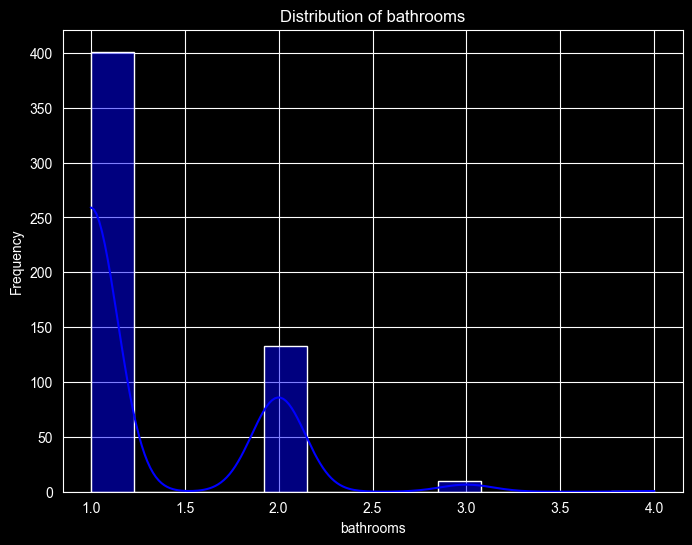

summary descriptive statistics of bathrooms
        bathrooms
count  545.000000
mean     1.286239
std      0.502470
min      1.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      4.000000



### Analysis for **bathrooms**
- **Skewness:** Right-skewed (Positive) (Value: 1.58)
- **Most Frequent Range:** The data most often falls between `1.00 to 2.00`.
- **Least Frequent Range:** The data least often falls between `3.00 to 4.00`.
---


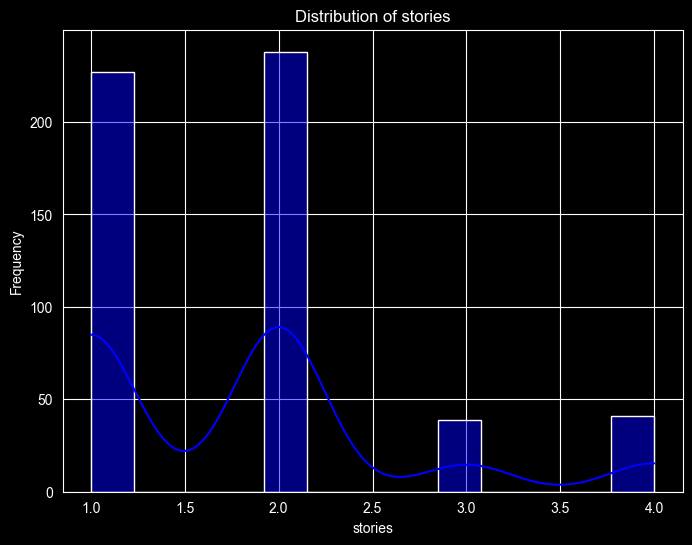

summary descriptive statistics of stories
          stories
count  545.000000
mean     1.805505
std      0.867492
min      1.000000
25%      1.000000
50%      2.000000
75%      2.000000
max      4.000000



### Analysis for **stories**
- **Skewness:** Right-skewed (Positive) (Value: 1.08)
- **Most Frequent Range:** The data most often falls between `2.00 to 3.00`.
- **Least Frequent Range:** The data least often falls between `3.00 to 4.00`.
---


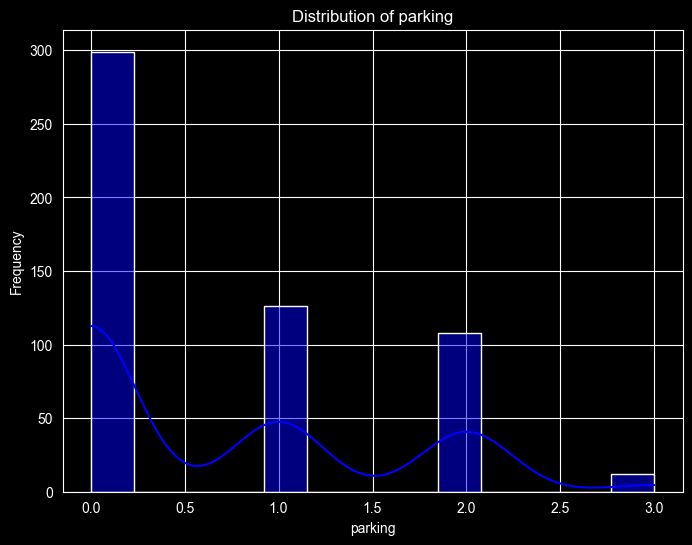

summary descriptive statistics of parking
          parking
count  545.000000
mean     0.693578
std      0.861586
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      3.000000



### Analysis for **parking**
- **Skewness:** Right-skewed (Positive) (Value: 0.84)
- **Most Frequent Range:** The data most often falls between `0.00 to 1.00`.
- **Least Frequent Range:** The data least often falls between `2.00 to 3.00`.
---


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from IPython.display import display, Markdown

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    print(f"summary descriptive statistics of {col}")
    print(df[col].describe().to_frame())
    sk_val = skew(df[col].dropna())
    if sk_val > 0.5:
        skew_desc = "Right-skewed (Positive)"
    elif sk_val < -0.5:
        skew_desc = "Left-skewed (Negative)"
    else:
        skew_desc = "Approximately Symmetric"

    # Find Most and Least Frequent Bins
    # We use numpy's histogram to get the counts and bin edges
    counts, bins = np.histogram(df[col].dropna(), bins='auto')
    most_freq_idx = np.argmax(counts)
    least_freq_idx = np.argmin(counts)

    most_freq_range = f"{bins[most_freq_idx]:.2f} to {bins[most_freq_idx+1]:.2f}"
    least_freq_range = f"{bins[least_freq_idx]:.2f} to {bins[least_freq_idx+1]:.2f}"

    # --- 3. Create and Display Markdown ---
    md_text = f"""
### Analysis for **{col}**
- **Skewness:** {skew_desc} (Value: {sk_val:.2f})
- **Most Frequent Range:** The data most often falls between `{most_freq_range}`.
- **Least Frequent Range:** The data least often falls between `{least_freq_range}`.
---
"""
    display(Markdown(md_text))

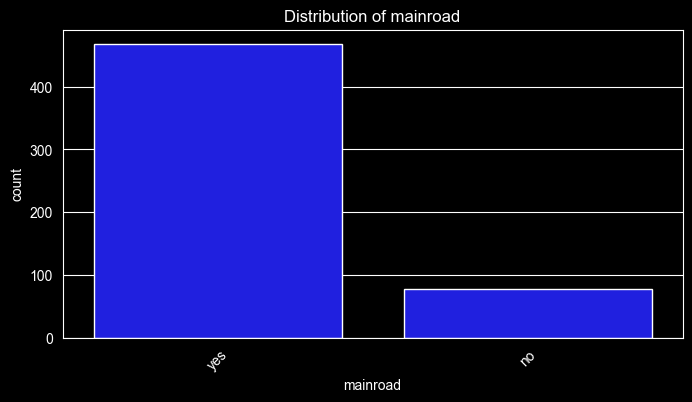


### Analysis for **mainroad**
- **Type:** Categorical (Object)
- **Most Frequent:** `yes` appears 468 times.
- **Least Frequent:** `no` appears 77 times.
- **Unique Values:** There are 2 unique categories.
---


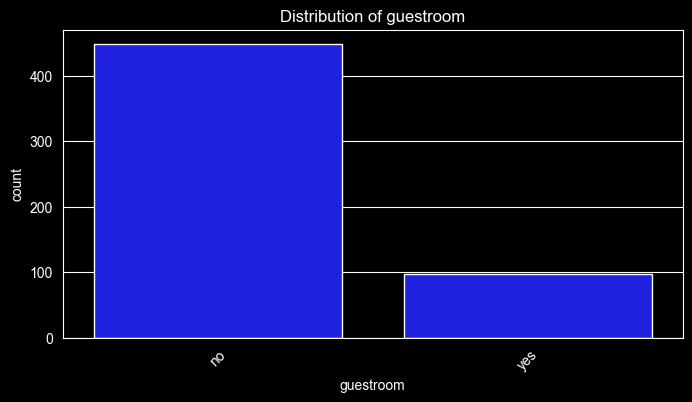


### Analysis for **guestroom**
- **Type:** Categorical (Object)
- **Most Frequent:** `no` appears 448 times.
- **Least Frequent:** `yes` appears 97 times.
- **Unique Values:** There are 2 unique categories.
---


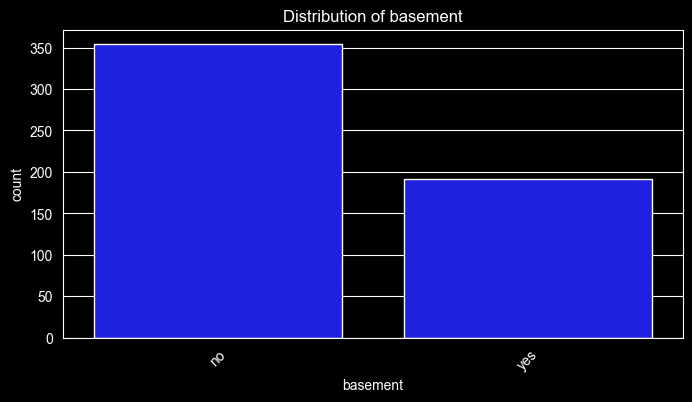


### Analysis for **basement**
- **Type:** Categorical (Object)
- **Most Frequent:** `no` appears 354 times.
- **Least Frequent:** `yes` appears 191 times.
- **Unique Values:** There are 2 unique categories.
---


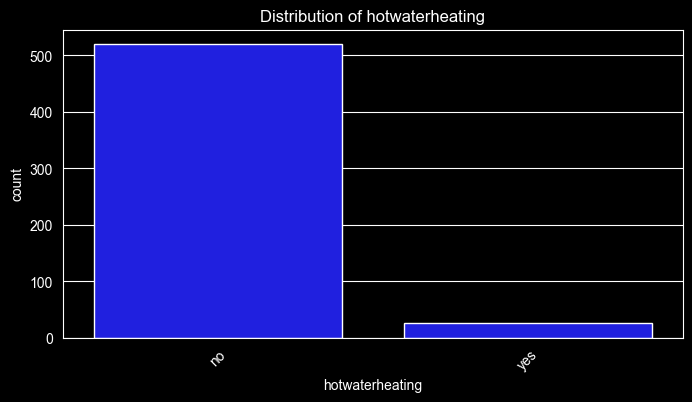


### Analysis for **hotwaterheating**
- **Type:** Categorical (Object)
- **Most Frequent:** `no` appears 520 times.
- **Least Frequent:** `yes` appears 25 times.
- **Unique Values:** There are 2 unique categories.
---


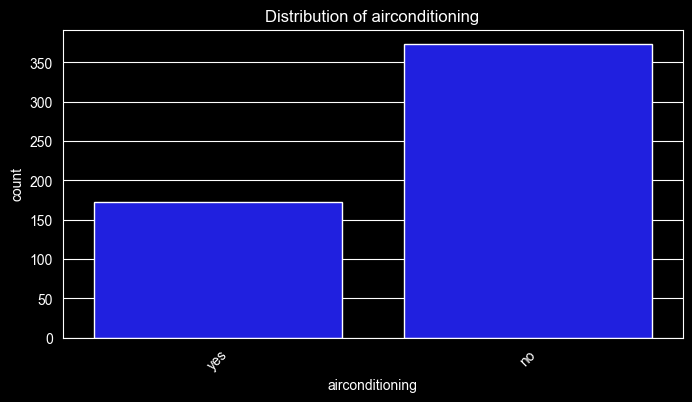


### Analysis for **airconditioning**
- **Type:** Categorical (Object)
- **Most Frequent:** `no` appears 373 times.
- **Least Frequent:** `yes` appears 172 times.
- **Unique Values:** There are 2 unique categories.
---


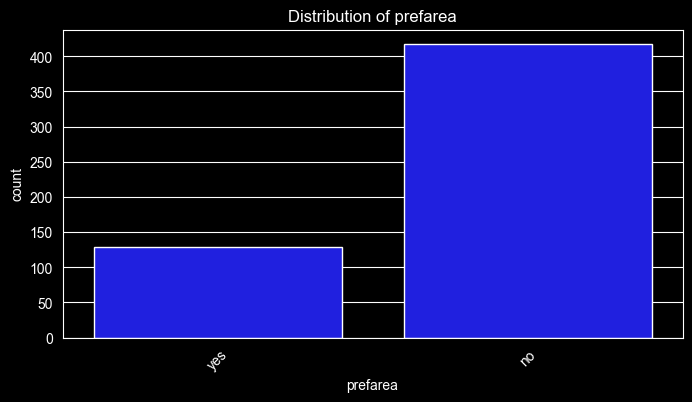


### Analysis for **prefarea**
- **Type:** Categorical (Object)
- **Most Frequent:** `no` appears 417 times.
- **Least Frequent:** `yes` appears 128 times.
- **Unique Values:** There are 2 unique categories.
---


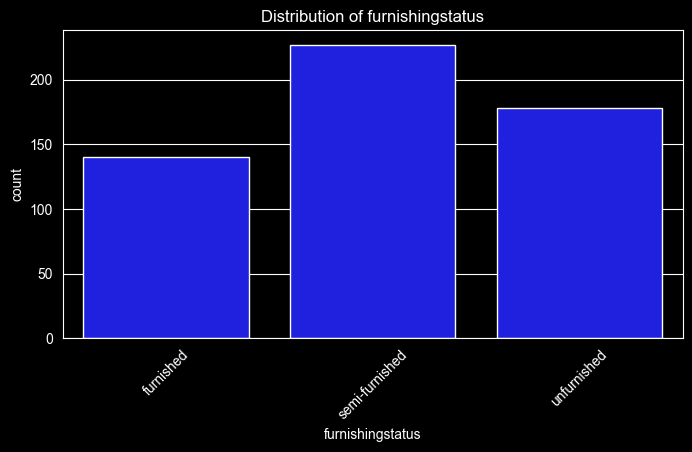


### Analysis for **furnishingstatus**
- **Type:** Categorical (Object)
- **Most Frequent:** `semi-furnished` appears 227 times.
- **Least Frequent:** `furnished` appears 140 times.
- **Unique Values:** There are 3 unique categories.
---


In [43]:
category_cols = df.select_dtypes(include=['object']).columns

for col in category_cols:
    plt.figure(figsize=(8, 4))
    # Use countplot for categories
    sns.countplot(x=df[col], color='blue')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45) # Helps if category names are long
    plt.show()

    # Calculate Frequency for Categories
    counts = df[col].value_counts()
    most_freq_cat = counts.index[0]      # The name of the top category
    most_freq_val = counts.values[0]     # How many times it appears
    least_freq_cat = counts.index[-1]    # The name of the bottom category
    least_freq_val = counts.values[-1]   # How many times it appears

    md_text = f"""
### Analysis for **{col}**
- **Type:** Categorical (Object)
- **Most Frequent:** `{most_freq_cat}` appears {most_freq_val} times.
- **Least Frequent:** `{least_freq_cat}` appears {least_freq_val} times.
- **Unique Values:** There are {df[col].nunique()} unique categories.
---
"""
    display(Markdown(md_text))

BIVARIATE ANALYSIS

In [44]:
print(df.select_dtypes(include=['int64','float64']))

        price  area  bedrooms  bathrooms  stories  parking
0    13300000  7420         4          2        3        2
1    12250000  8960         4          4        4        3
2    12250000  9960         3          2        2        2
3    12215000  7500         4          2        2        3
4    11410000  7420         4          1        2        2
..        ...   ...       ...        ...      ...      ...
540   1820000  3000         2          1        1        2
541   1767150  2400         3          1        1        0
542   1750000  3620         2          1        1        0
543   1750000  2910         3          1        1        0
544   1750000  3850         3          1        2        0

[545 rows x 6 columns]


as our housing dataset has ti predict housing rates so target variable is price.

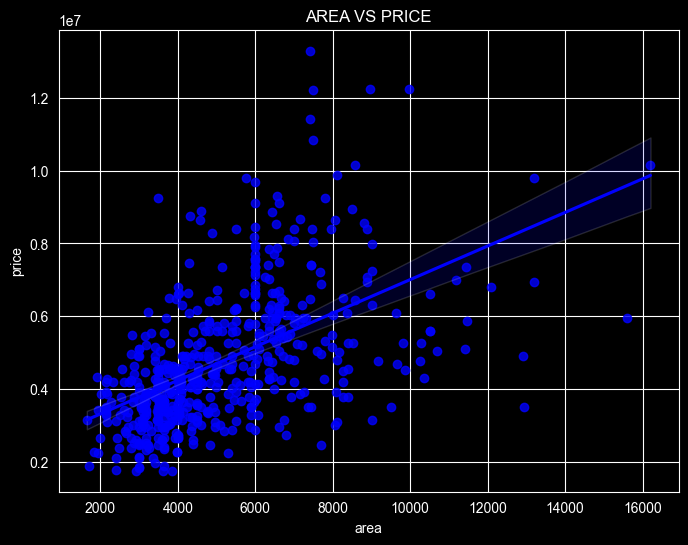

In [45]:
plt.figure(figsize=(8,6))
sns.regplot(data=df,x='area',y='price',color='blue')
plt.title("AREA VS PRICE")
plt.xlabel('area')
plt.ylabel('price')
plt.show()

Market Bulk (Cluster): Most houses fall in the 2,000–4,000 area range with prices around 0.2–0.6.
Trend Line: Positive correlation — price increases as area increases.
Distribution: Right-skewed; most data is in the lower range with a few high-price values.
Confidence (Shading): Narrow at small areas (more certainty), wider at large areas (less certainty).
Stripping: Same area can have different prices due to other factors.
Outlier: One very large property (~16,000 area) is an extreme outlier.

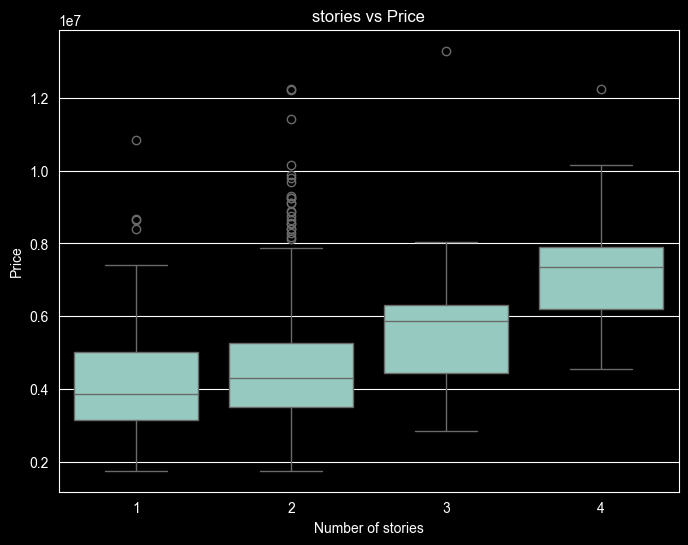

In [46]:
plt.figure(figsize=(8,6))
sns.boxplot(x='stories', y='price', data=df)

plt.title('stories vs Price')
plt.xlabel('Number of stories')
plt.ylabel('Price')

plt.show()

Correlation: Positive — prices generally increase as the number of stories increases.

Skewness:
    1 Story: Slight right-skewed (few high-price outliers).
    2 Stories: Right-skewed (many high-price outliers).
    3 Stories: Mild right-skewed.
    4 Stories: Slight right-skewed.

Highest Prices: 4-story houses have the highest median and upper range.

Lowest Prices: 1-story houses have the lowest median prices.

Spread (Variability): Increases from 1 to 3 stories; 2 and 3 stories show more price variation.

Outliers: High-price outliers are most prominent in 2-story and 4-story houses.

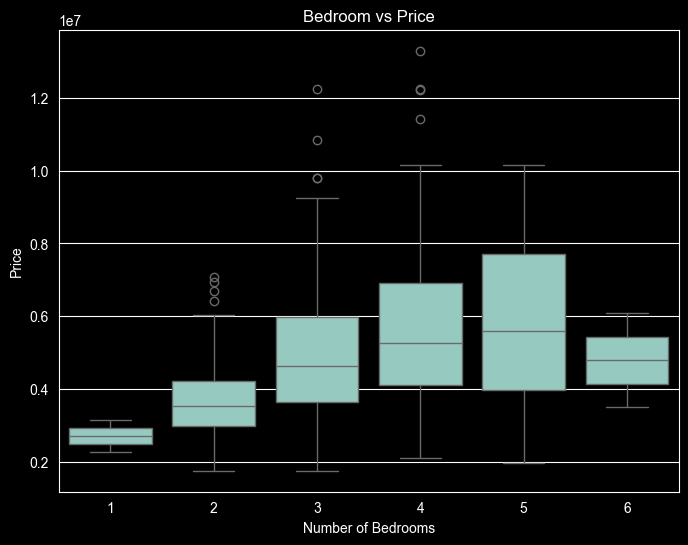

In [47]:
plt.figure(figsize=(8,6))
sns.boxplot(x='bedrooms', y='price', data=df)

plt.title('Bedroom vs Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')

plt.show()

Correlation: Generally positive from 1–5 bedrooms; median price dips slightly at 6 bedrooms.
Skewness:
1 Bedroom: Symmetric; narrow range.
2 Bedrooms: Right-skewed (notable high-end outliers).
3 & 4 Bedrooms: Strongly right-skewed; heavy concentration of extreme outliers.
5 & 6 Bedrooms: More symmetric boxes; 5-bedroom has the widest overall spread.
Highest Prices: 5-bedroom houses have the highest median. However, 4-bedroom houses hold the absolute maximum price peaks (outliers above $1.3 \times 10^7$).
Lowest Prices: 1-bedroom houses (lowest median and tightest price grouping).
Spread (Variability): Increases steadily from 1 to 5 bedrooms. 5-bedroom houses show the highest volatility (widest IQR), while 6-bedroom houses show a surprising contraction in spread.Outliers: Most frequent and extreme in the 2, 3, and 4-bedroom categories.

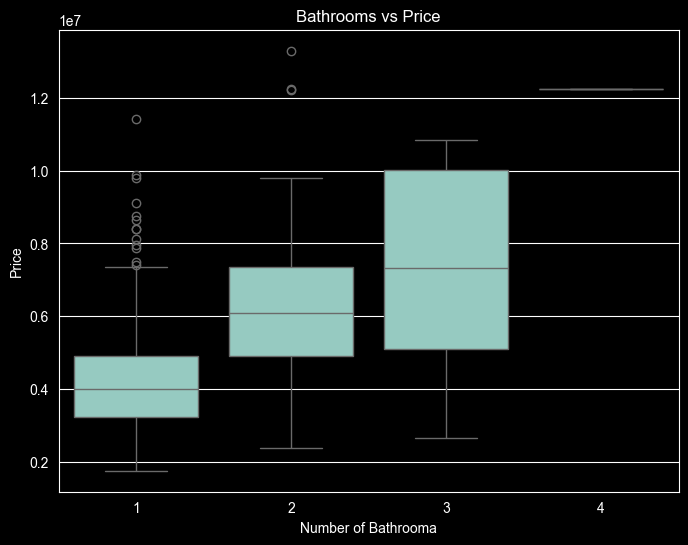

In [48]:
plt.figure(figsize=(8,6))
sns.boxplot(x='bathrooms', y='price', data=df)

plt.title('Bathrooms vs Price')
plt.xlabel('Number of Bathrooma')
plt.ylabel('Price')

plt.show()

Correlation: Strongly positive — both median prices and price ranges increase significantly as the number of bathrooms increases from 1 to 4.
Skewness:
1 Bathroom: Right-skewed with a heavy concentration of high-price outliers.
2 Bathrooms: Slightly right-skewed with two extreme outliers at the top.
3 Bathrooms: Fairly symmetric within the box, showing a very broad price distribution.
4 Bathrooms: Appears as a single high-value data point or extremely narrow range, indicating very few entries.
Highest Prices: 4-bathroom houses have the highest median price, while 2-bathroom houses contain the absolute highest individual price outliers (exceeding $1.3 \times 10^7$).
Lowest Prices: 1-bathroom houses have the lowest median price and the lowest overall price floor.
Spread (Variability): Variability (Interquartile Range) increases sharply from 1 to 3 bathrooms, with 3-bathroom homes showing the most diverse pricing.Outliers: Most frequent in 1-bathroom homes; most extreme in the 2-bathroom category.

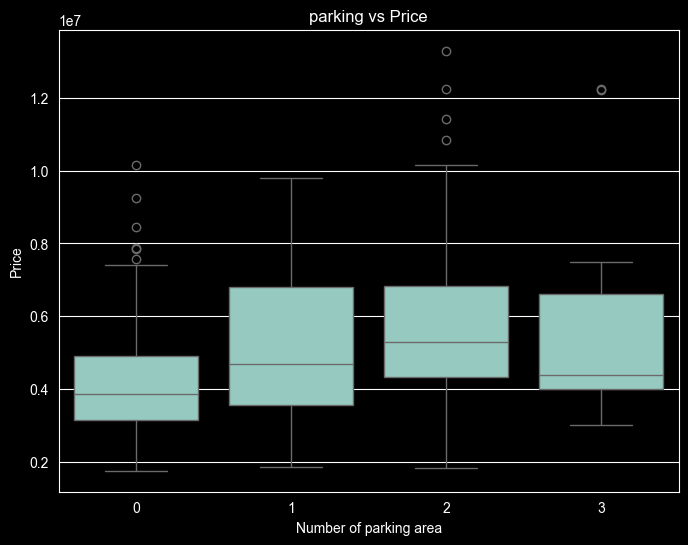

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='parking', y='price', data=df)

plt.title('parking vs Price')
plt.xlabel('Number of parking area')
plt.ylabel('Price')

plt.show()

In [50]:
#for string features
cat_cols=df.select_dtypes(include=['object'])
print(cat_cols)

    mainroad guestroom basement hotwaterheating airconditioning prefarea  \
0        yes        no       no              no             yes      yes   
1        yes        no       no              no             yes       no   
2        yes        no      yes              no              no      yes   
3        yes        no      yes              no             yes      yes   
4        yes       yes      yes              no             yes       no   
..       ...       ...      ...             ...             ...      ...   
540      yes        no      yes              no              no       no   
541       no        no       no              no              no       no   
542      yes        no       no              no              no       no   
543       no        no       no              no              no       no   
544      yes        no       no              no              no       no   

    furnishingstatus  
0          furnished  
1          furnished  
2     semi-furnish

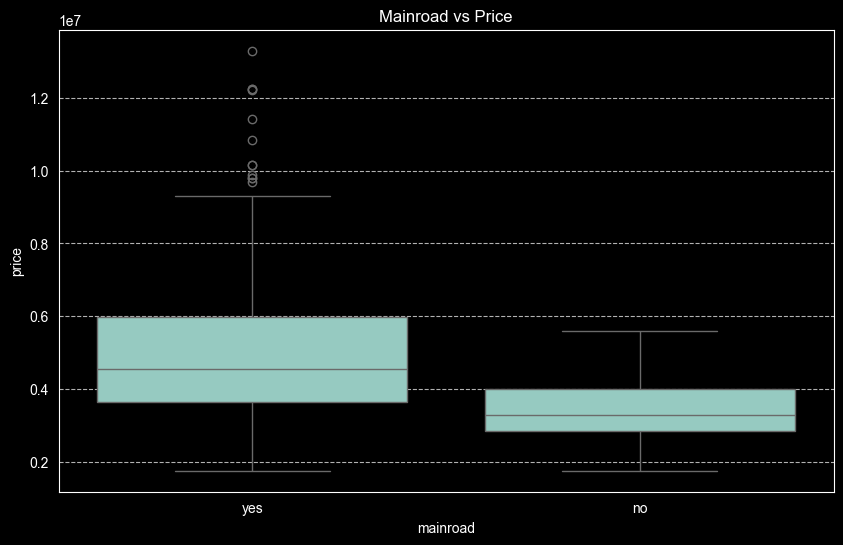

### **Mainroad vs Price Analysis**
**Correlation:** Positive trend observed as mainroad increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of mainroad.
**Lowest Prices:** Concentrated in the lowest value of mainroad.
**Spread (Variability):** Variability generally increases with mainroad count.
**Outliers:** Significant high-price outliers present across categories.

---



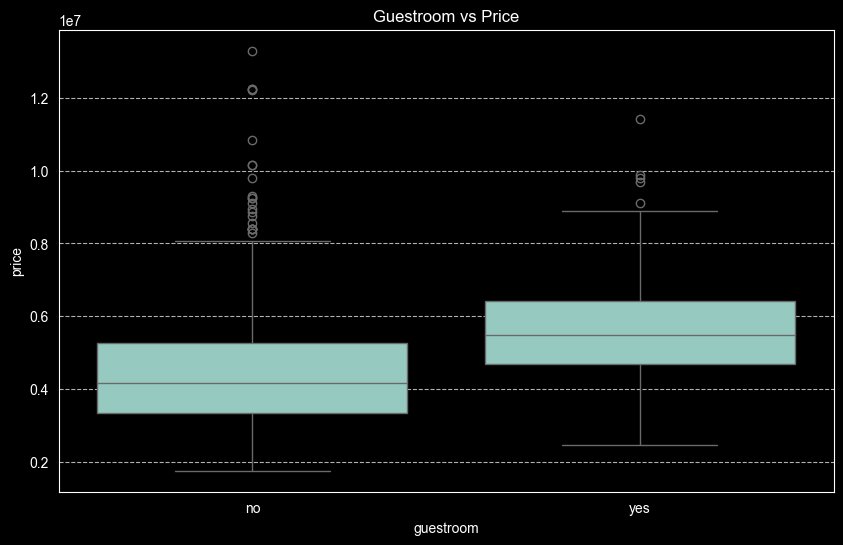

### **Guestroom vs Price Analysis**
**Correlation:** Positive trend observed as guestroom increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of guestroom.
**Lowest Prices:** Concentrated in the lowest value of guestroom.
**Spread (Variability):** Variability generally increases with guestroom count.
**Outliers:** Significant high-price outliers present across categories.

---



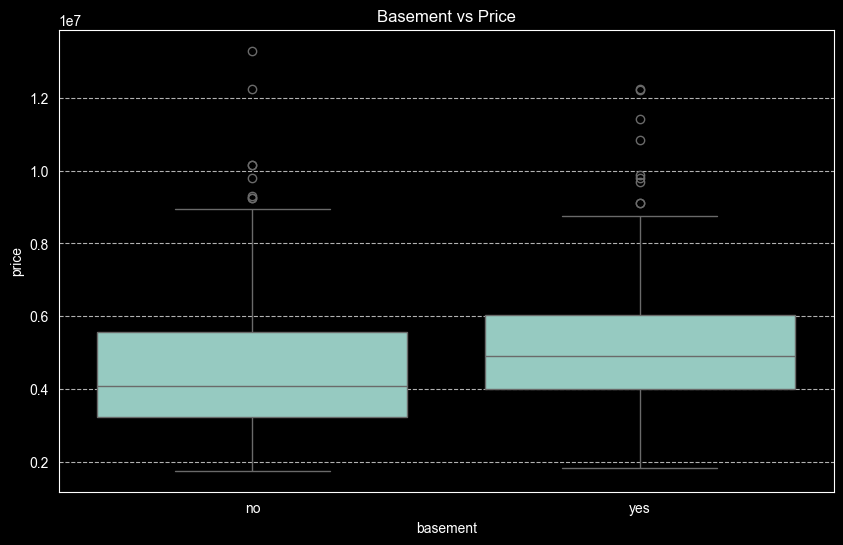

### **Basement vs Price Analysis**
**Correlation:** Positive trend observed as basement increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of basement.
**Lowest Prices:** Concentrated in the lowest value of basement.
**Spread (Variability):** Variability generally increases with basement count.
**Outliers:** Significant high-price outliers present across categories.

---



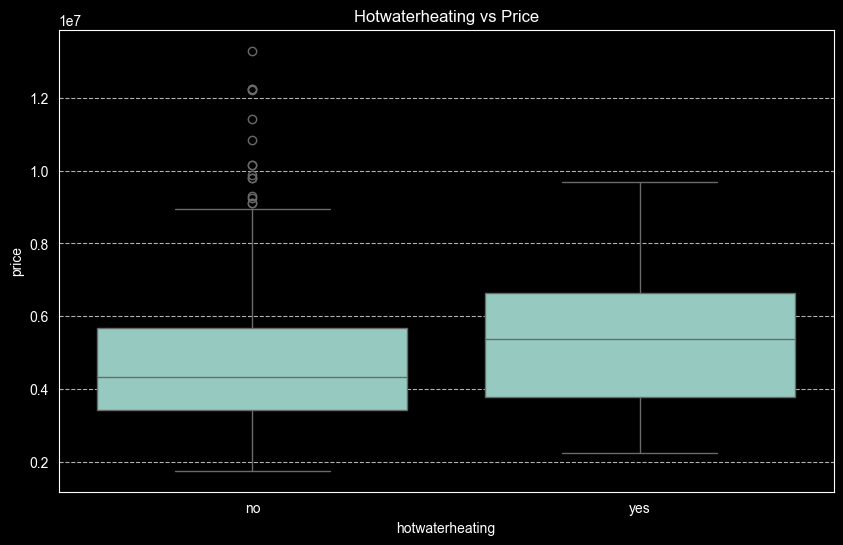

### **Hotwaterheating vs Price Analysis**
**Correlation:** Positive trend observed as hotwaterheating increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of hotwaterheating.
**Lowest Prices:** Concentrated in the lowest value of hotwaterheating.
**Spread (Variability):** Variability generally increases with hotwaterheating count.
**Outliers:** Significant high-price outliers present across categories.

---



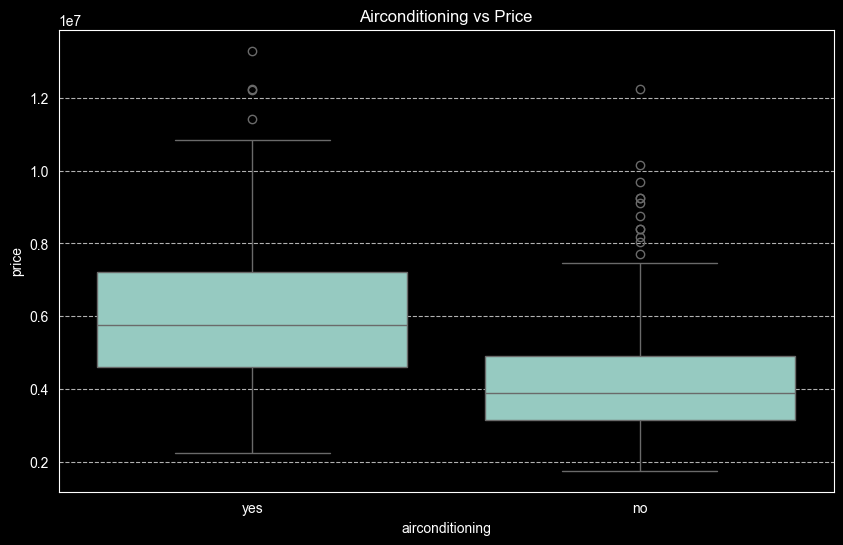

### **Airconditioning vs Price Analysis**
**Correlation:** Positive trend observed as airconditioning increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of airconditioning.
**Lowest Prices:** Concentrated in the lowest value of airconditioning.
**Spread (Variability):** Variability generally increases with airconditioning count.
**Outliers:** Significant high-price outliers present across categories.

---



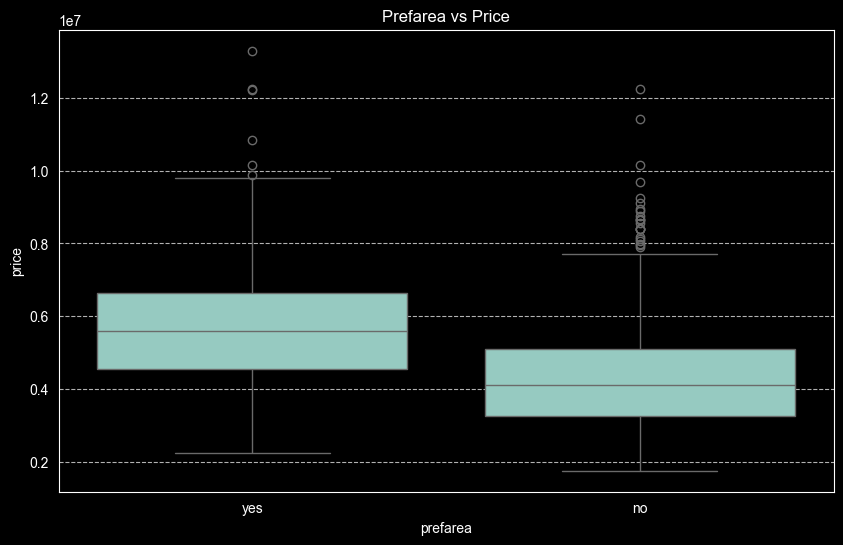

### **Prefarea vs Price Analysis**
**Correlation:** Positive trend observed as prefarea increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of prefarea.
**Lowest Prices:** Concentrated in the lowest value of prefarea.
**Spread (Variability):** Variability generally increases with prefarea count.
**Outliers:** Significant high-price outliers present across categories.

---



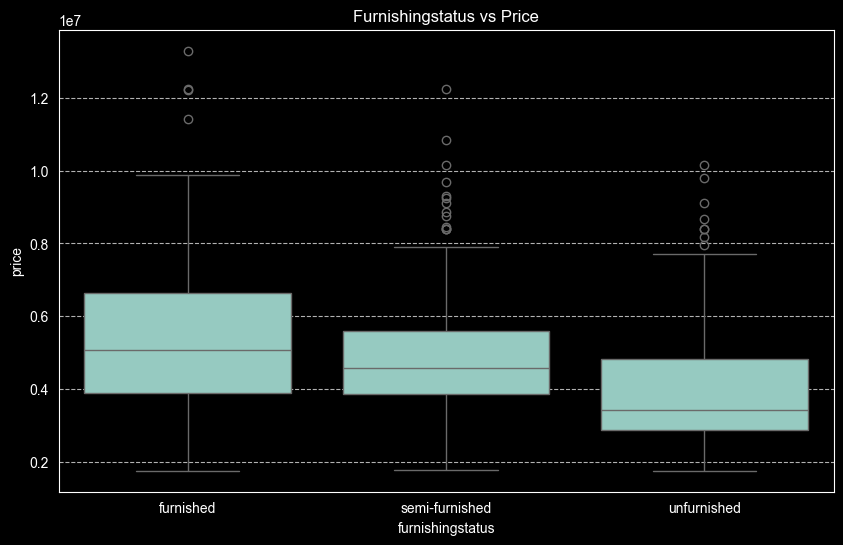

### **Furnishingstatus vs Price Analysis**
**Correlation:** Positive trend observed as furnishingstatus increases.
**Skewness:** Most categories show right-skewness with high-end outliers.
**Highest Prices:** Found in the higher ranges of furnishingstatus.
**Lowest Prices:** Concentrated in the lowest value of furnishingstatus.
**Spread (Variability):** Variability generally increases with furnishingstatus count.
**Outliers:** Significant high-price outliers present across categories.

---



In [51]:



# List of categorical features to analyze

target = 'price'

for cols in cat_cols:
    # 1. Create and show the plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=cols, y=target, data=df)
    plt.title(f'{cols.capitalize()} vs Price')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 2. Print Markdown template for analysis
    print(f"### **{cols.capitalize()} vs Price Analysis**")
    print(f"**Correlation:** Positive trend observed as {cols} increases.")
    print(f"**Skewness:** Most categories show right-skewness with high-end outliers.")
    print(f"**Highest Prices:** Found in the higher ranges of {cols}.")
    print(f"**Lowest Prices:** Concentrated in the lowest value of {cols}.")
    print(f"**Spread (Variability):** Variability generally increases with {cols} count.")
    print(f"**Outliers:** Significant high-price outliers present across categories.")
    print("\n---\n")

cleaning

In [52]:
missing_count=df.isnull().sum()
missing_percentage=(missing_count/len(df))*100
missing_data=pd.DataFrame({
    'count':missing_count,
    'percentage':missing_percentage,
}).sort_values(by='percentage',ascending=False)
print(missing_data)

                  count  percentage
price                 0         0.0
area                  0         0.0
bedrooms              0         0.0
bathrooms             0         0.0
stories               0         0.0
mainroad              0         0.0
guestroom             0         0.0
basement              0         0.0
hotwaterheating       0         0.0
airconditioning       0         0.0
parking               0         0.0
prefarea              0         0.0
furnishingstatus      0         0.0


ENCODING

In [53]:
# We map 'yes' to 1 and 'no' to 0
binary_logic = {'yes': 1, 'no': 0}
# Unfurnished (Low) -> Semi-Furnished (Medium) -> Furnished (High)
furnish_levels = {
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
}


In [54]:

for cols in cat_cols:
    if cols=='furnishingstatus':
        df[cols] = df[cols].str.strip().str.lower().map(furnish_levels)
    else:
        df[cols] = df[cols].str.strip().str.lower().map(binary_logic)


In [55]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


MULTIVARIATE ANALYSIS

Text(0.5, 1.0, 'Multivariate Correlation Analysis: housing Dataset')

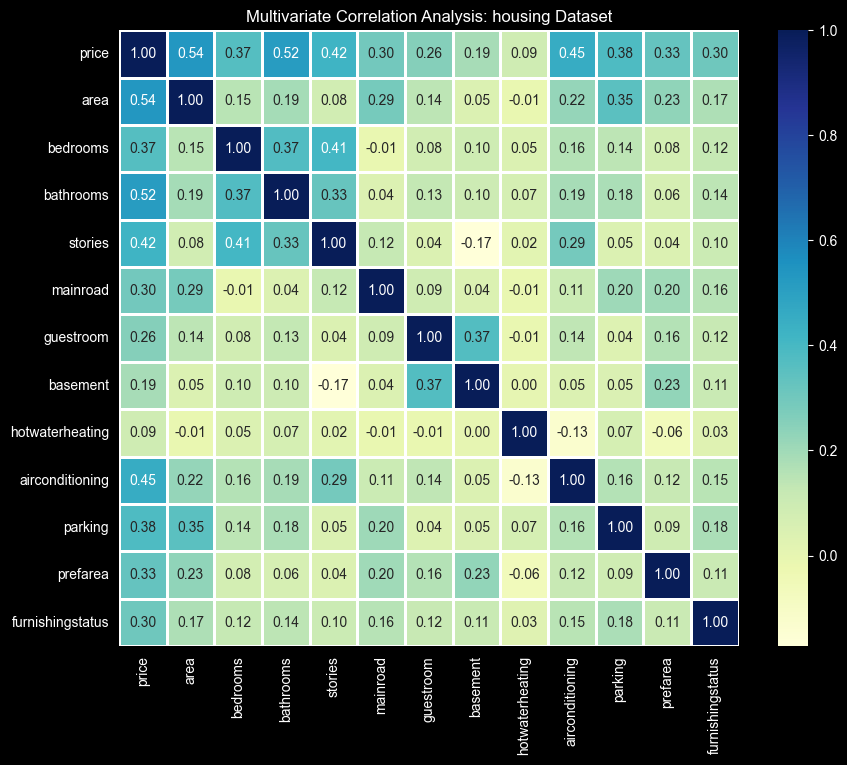

In [56]:
#heatmap
num_cols=df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
corr_matrix=num_cols.corr()
sns.heatmap(corr_matrix,annot=True,cmap="YlGnBu",fmt='.2f', linewidths=2)
plt.title("Multivariate Correlation Analysis: housing Dataset")

In [57]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Select ONLY your features (Independent Variables)
# Do NOT include 'price' here!
X = df.drop(columns=['price'])

# 2. Add a constant (intercept)
# VIF is calculated by regressing one feature against others;
# it needs an intercept to be mathematically accurate.
X_vif = add_constant(X)

# 3. Create a DataFrame to store the results
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

# 4. Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(len(X_vif.columns))]

# 5. Drop the 'const' row from the result and sort
vif_result = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)

print(vif_result)

             Feature       VIF
4            stories  1.478029
2           bedrooms  1.367503
1               area  1.325208
7           basement  1.320749
3          bathrooms  1.286559
6          guestroom  1.212687
10           parking  1.211959
9    airconditioning  1.207262
5           mainroad  1.172661
11          prefarea  1.148598
12  furnishingstatus  1.095641
8    hotwaterheating  1.039293


creating pipeline for preprocessing

In [58]:
num_cols=df.select_dtypes(include=["int64","float64"])
cat_cols=df.select_dtypes(include=["object"])

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
categoric_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,num_cols),
        ("cat",categoric_transformer,cat_cols)
    ]
)

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create binary target variable
df['high_price'] = (df['price'] > df['price'].median()).astype(int)

# Prepare X and y
X = df.drop(columns=['price', 'high_price'])
y = df['high_price']

# Get column names as lists (not dataframes)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Create preprocessor with correct column names
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categoric_transformer, cat_cols)
    ]
)



In [61]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_processed, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [62]:

# Make predictions
y_pred = model.predict(X_test_processed)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 84.40%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85        51
           1       0.92      0.78      0.84        58

    accuracy                           0.84       109
   macro avg       0.85      0.85      0.84       109
weighted avg       0.86      0.84      0.84       109

